# 01 — Data Quality and Exploratory Analysis

**European Bank Customer Segmentation & Churn Analytics**

This notebook is a beginner-friendly walkthrough of the data-quality checks, segmentation
rules, and headline KPIs used throughout this project. It calls tested functions from
`european_bank_churn` instead of duplicating business logic, so results here always match
the Streamlit dashboard and the automated test suite.

**Privacy note:** the source workbook (`data/raw/European_Bank.xlsx`) is a private, local-only
file. It is excluded from version control (see `.gitignore`) and this notebook never prints
row-level customer data — only aggregated, de-identified summaries. Before committing this
notebook, always run *Restart Kernel & Clear Output* if you have experimented with any
row-level inspection.

**Reproducibility:** every figure below is generated from `data/raw/European_Bank.xlsx` using
`random_state=42` and the same functions covered by `tests/`, so results are deterministic
and auditable end to end.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from european_bank_churn import (
    load_excel, overall_kpis, prepare_data, segment_summary, validate_dataset
)
from european_bank_churn.analytics import (
    engagement_risk_ratio, geography_age_matrix, profile_comparison, high_value_summary
)
from european_bank_churn.modeling import (
    train_model_comparison, evaluate_probabilities, cross_validate_models
)

## 1. Load the source workbook

We load the raw Excel workbook exactly as supplied, without modifying it. Only its **shape**
and **column names** are inspected here — no individual customer rows are displayed.

In [2]:
WORKBOOK = PROJECT_ROOT / 'data' / 'raw' / 'European_Bank.xlsx'
raw = load_excel(WORKBOOK)
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]}")
print(f"Column names: {list(raw.columns)}")

Rows: 10,000
Columns: 14
Column names: ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## 2. Data-quality validation

`validate_dataset` runs the full battery of checks documented in `docs/data_dictionary.md`:
required-column presence, missing values, duplicate IDs, numeric-type consistency, binary-flag
integrity, valid ranges for age/balance/products, and expected category values for
`Geography` and `Gender`. It **never mutates the data** — it only reports findings.

In [3]:
findings = validate_dataset(raw)
for item in findings:
    print(f"[{item['level'].upper():7}] {item['message']}")

[INFO   ] Year has one value only, so it is excluded from ML features.


**Interpretation.** The dataset passes every structural and range check. The single `INFO`
finding flags that `Year` is a constant column (a single-snapshot dataset extract) — the
pipeline automatically excludes it from model features and segmentation, so no manual cleanup
is required.

## 3. Prepare data and compute headline KPIs

`prepare_data` performs type coercion and builds the five non-overlapping segmentation fields
(`AgeGroup`, `CreditBand`, `TenureGroup`, `BalanceSegment`, `HighValue`) using the thresholds
defined in `config.py`. `overall_kpis` then summarizes the whole (filtered) population.

In [4]:
data, thresholds = prepare_data(raw)
kpis = overall_kpis(data)

print("Overall KPIs")
for key, value in kpis.items():
    print(f"  {key:20}: {value}")

print()
print("Segmentation thresholds")
for key, value in thresholds.items():
    print(f"  {key:26}: {value:,.2f}")

Overall KPIs
  customers           : 10000
  churners            : 2037
  retained            : 7963
  churn_rate          : 0.2037
  riskiest_geography  : Germany (1.59x)

Segmentation thresholds
  positive_balance_median   : 119,839.69
  high_value_threshold      : 127,644.24


**Interpretation.** Of 10,000 customers, **20.37% churned** (2,037 customers) in this
snapshot. `Germany` is the highest-risk geography at roughly **1.59×** the overall churn
rate — a signal worth investigating further in the geography breakdown below. The high-value
threshold (75th balance percentile) is **€127,644.24**.

## 4. Churn by geography

`segment_summary` reports customer count, churners, churn rate, average balance/salary, and
each segment's share of total churners (`ChurnContribution`) for any segmentation column.

In [5]:
geography = segment_summary(data, 'Geography').sort_values('ChurnRate', ascending=False)
print(geography.round(4).to_string(index=False))

Geography  Customers  Churners  ChurnRate  AverageBalance  AverageSalary  ChurnContribution
  Germany       2509       814     0.3244     119730.1161    101113.4351             0.3996
    Spain       2477       413     0.1667      61818.1478     99440.5723             0.2027
   France       5014       810     0.1615      62092.6365     99899.1808             0.3976


**Interpretation.** Germany stands out sharply: **32.44% churn** versus **16.15%** (France)
and **16.67%** (Spain) — roughly double the other two markets — despite holding a smaller
customer base (2,509 vs. 5,014 and 2,477). Germany alone contributes **~40%** of all churners
even though it is only ~25% of the customer base, making it the top retention-strategy
priority by geography.

## 5. Churn by age group

Age bands are fixed, non-overlapping ranges (`<30`, `30–45`, `46–59`, `60+`) so churn rates
are directly comparable across groups.

In [6]:
age_groups = segment_summary(data, 'AgeGroup').sort_values('ChurnRate', ascending=False)
print(age_groups.round(4).to_string(index=False))

AgeGroup  Customers  Churners  ChurnRate  AverageBalance  AverageSalary  ChurnContribution
   46-59       1585       810     0.5110      81926.9820    100326.1530             0.3976
     60+        526       147     0.2795      75136.0978     97562.1425             0.0722
   30-45       6248       956     0.1530      75951.2551    100042.3012             0.4693
     <30       1641       124     0.0756      73698.7186    100855.2478             0.0609


**Notable finding.** The **46–59** age band churns at **51.1%** — more than three times the
rate of the 30–45 group (15.3%) and nearly seven times the under-30 group (7.6%). This is the
single strongest churn signal in the dataset and should be the primary demographic lens for
any retention campaign, ahead of geography alone.

## 6. Geography × age interaction

Combining both dimensions shows whether the age effect is consistent across markets or
concentrated in one region.

In [7]:
matrix = geography_age_matrix(data)
print(matrix.round(4).to_string())

AgeGroup      <30   30-45   46-59     60+
Geography                                
France     0.0520  0.1187  0.4547  0.2482
Germany    0.1263  0.2530  0.6728  0.4146
Spain      0.0794  0.1252  0.4083  0.2171


**Interpretation.** The 46–59 churn spike is **not isolated to one market** — it appears in
all three geographies (France 45.5%, Germany 67.3%, Spain 40.8%) but is most extreme in
Germany. This confirms two independent, compounding risk factors: **being in Germany** and
**being aged 46–59** — customers who are both face the highest observed churn rate in the
dataset (67.3%).

## 7. Engagement and high-value customer risk

In [8]:
risk_ratio = engagement_risk_ratio(data)
print(f"Inactive-to-active churn risk ratio: {risk_ratio:.2f}x")

premium, hv_summary = high_value_summary(data, thresholds['high_value_threshold'])
print()
print("High-value customer summary (balance >= 75th percentile):")
for key, value in hv_summary.items():
    if key in ('customers', 'churners'):
        print(f"  {key:16}: {value:,}")
    elif key == 'balance_at_risk':
        print(f"  {key:16}: €{value:,.2f}")
    else:
        print(f"  {key:16}: {value:.4f}")

Inactive-to-active churn risk ratio: 1.88x

High-value customer summary (balance >= 75th percentile):
  threshold       : 127644.2400
  customers       : 2,500
  churners        : 592
  churn_rate      : 0.2368
  balance_at_risk : €88,654,932.44


**Interpretation.** Inactive members churn at **1.88×** the rate of active members —
confirming engagement is a strong, actionable retention lever independent of demographics.
Among high-value customers (top quartile by balance), churn is **23.68%** — noticeably
*above* the overall rate of 20.37% — meaning churn is *not* concentrated only among
low-value customers. Roughly **€88.7 million** in balance sits with churned high-value
customers, which is an exposure figure, **not** a recognized revenue loss.

## 8. Retained vs. churned customer profile

In [9]:
comparison = profile_comparison(data)
print(comparison.to_string(index=False))

ChurnLabel  CreditScore   Age  Tenure  Balance  NumOfProducts  EstimatedSalary
   Churned       645.35 44.84    4.93 91108.54           1.48        101465.68
  Retained       651.85 37.41    5.03 72745.30           1.54         99738.39


**Interpretation.** Churned customers are, on average, **older** (44.8 vs. 37.4 years) and
carry a **higher balance** (€91,109 vs. €72,745) than retained customers, while credit score,
tenure, product count, and salary are broadly similar between the two groups. This reinforces
age and balance as the most differentiating factors — consistent with the segment findings
above.

## 9. Visual summary

A quick static view of churn rate by geography and by age group. The full interactive
Plotly charts (with drill-down filters) live in the Streamlit dashboard (`app.py`).

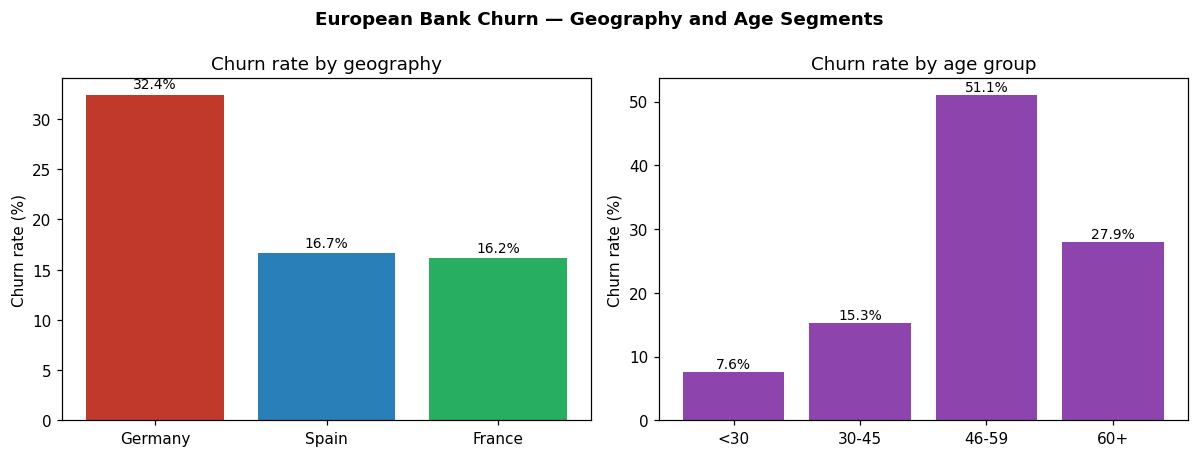

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

geo = segment_summary(data, 'Geography').sort_values('ChurnRate', ascending=False)
axes[0].bar(geo['Geography'], geo['ChurnRate'] * 100, color=['#c0392b', '#2980b9', '#27ae60'])
axes[0].set_title('Churn rate by geography')
axes[0].set_ylabel('Churn rate (%)')
for i, v in enumerate(geo['ChurnRate'] * 100):
    axes[0].text(i, v + 0.6, f"{v:.1f}%", ha='center', fontsize=9)

age = segment_summary(data, 'AgeGroup')
order = ['<30', '30-45', '46-59', '60+']
age = age.set_index('AgeGroup').reindex(order).reset_index()
axes[1].bar(age['AgeGroup'], age['ChurnRate'] * 100, color='#8e44ad')
axes[1].set_title('Churn rate by age group')
axes[1].set_ylabel('Churn rate (%)')
for i, v in enumerate(age['ChurnRate'] * 100):
    axes[1].text(i, v + 0.6, f"{v:.1f}%", ha='center', fontsize=9)

fig.suptitle('European Bank Churn — Geography and Age Segments', fontsize=12, fontweight='bold')
fig.tight_layout()

## 10. Quick model snapshot

The full model-comparison workflow (feature engineering, pipelines, calibration, and
fairness auditing) lives in `european_bank_churn.modeling` and `notebooks/` is intentionally
kept lightweight. Here we train both classifiers on a single stratified 80/20 split
(`random_state=42`) purely to sanity-check the pipeline end to end.

In [11]:
comparison = train_model_comparison(data)
logistic_metrics = evaluate_probabilities(comparison['y_test'], comparison['logistic_probabilities'])
forest_metrics = evaluate_probabilities(comparison['y_test'], comparison['random_forest_probabilities'])

summary = pd.DataFrame([
    {'Model': 'Logistic Regression', **logistic_metrics},
    {'Model': 'Random Forest', **forest_metrics},
]).drop(columns='confusion_matrix')
print(summary.round(4).to_string(index=False))
print()
print("Run metadata:", comparison['metadata'])

              Model  accuracy  precision  recall     f1  roc_auc  pr_auc  brier_score
Logistic Regression    0.7135     0.3872  0.7002 0.4987   0.7772  0.4679       0.1942
      Random Forest    0.8315     0.5729  0.6757 0.6201   0.8612  0.6894       0.1293

Run metadata: {'model_version': '1.1.0', 'dataset_fingerprint': '5e9623df8b1e', 'random_state': 42, 'training_rows': 8000, 'test_rows': 2000}


**Interpretation.** On this single holdout split, Random Forest clearly outperforms Logistic
Regression on every ranking and calibration metric (ROC-AUC 0.86 vs. 0.78; Brier score 0.13 vs.
0.19 — lower is better). Logistic Regression remains valuable as an **explainable baseline**
(signed coefficients show direction of effect), while Random Forest is the stronger candidate
for a production-style ranking model.

## 11. Five-fold cross-validation (robustness check)

A single split can be lucky or unlucky. Five-fold stratified cross-validation confirms the
snapshot above is stable, not an artifact of one particular split.

In [12]:
cv_results = cross_validate_models(data, folds=5, random_state=42)
print(cv_results.round(4).to_string(index=False))

              Model  Folds  ROC-AUCMean  ROC-AUCStd  PR-AUCMean  PR-AUCStd  RecallMean  RecallStd  PrecisionMean  PrecisionStd  F1Mean  F1Std
Logistic Regression      5       0.7693      0.0162      0.4597     0.0308      0.6912     0.0387         0.3838        0.0122  0.4934 0.0179
      Random Forest      5       0.8611      0.0076      0.6801     0.0184      0.6731     0.0278         0.5804        0.0259  0.6231 0.0238


**Interpretation.** Both models are stable across folds (small standard deviations relative
to their means). Random Forest is consistently stronger on ROC-AUC (0.861 ± 0.008) and PR-AUC
(0.680 ± 0.018) than Logistic Regression (0.769 ± 0.016 and 0.460 ± 0.031), confirming the
single-split snapshot above was representative, not a lucky draw. These figures match the
project README, which is itself generated from this same tested code path.

## Interpretation checklist

- Report counts **with** percentages — a rate alone hides how many customers it represents.
- Treat every segment difference as an **association**, not a proven cause; none of this
  analysis is a causal or controlled experiment.
- Investigate **small groups** (e.g. `60+`, n=526) before recommending action — smaller samples
  produce noisier rates.
- Do **not** commit executed output containing customer-level rows; keep outputs aggregated,
  as done throughout this notebook.
- Cross-check any single-split model result against the 5-fold cross-validation table before
  treating it as reliable.

## Next steps

- For interactive, filterable exploration of every segment above, run the Streamlit
  dashboard: `streamlit run app.py`.
- For the fully documented methodology, KPI formulas, and model card, see `docs/methodology.md`
  and `docs/model_card.md`.
- For a capacity-constrained retention-campaign ROI scenario built on these model scores, see
  `european_bank_churn.business.simulate_retention_campaign` and `reports/research_paper.md`.